In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

df = pd.read_excel('School data.xlsx')

print("shape of dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())

df.info()
df.head()

shape of dataset: (5200, 17)

Column names: ['School_ID', 'District', 'Block', 'Urban_Rural', '%_Math_Score', '%_Language_Score', '%_Science_Score', 'Teacher_Student_Ratio', 'Avg_Teacher_Experience_Years', 'Teacher_Trainings_Attended', 'Electricity_Available', 'Internet_Available', 'Functional_Toilets', 'Library_Available', '%_Marginalized_Students', '%_Students_With_Home_Internet', 'Parent_Literacy_Rate']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   School_ID                      5200 non-null   object 
 1   District                       5200 non-null   object 
 2   Block                          5200 non-null   object 
 3   Urban_Rural                    5200 non-null   object 
 4   %_Math_Score                   4942 non-null   float64
 5   %_Language_Score               5200 non-null   float64
 6 

,School_ID,District,Block,Urban_Rural,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
0,SCH_1,District_C,Block_C1,Rural,43.32,48.87,48.89,40.1,5.7,1,1,0.0,1,0,29.7,5.7,33.9
1,SCH_2,District_A,Block_A3,Rural,81.98,83.18,83.26,NaN,5.8,1,1,0.0,0,0,36.1,4.0,40.6
2,SCH_3,District_B,Block_B1,Rural,44.68,46.38,40.19,29.9,7.1,2,1,1.0,0,0,38.9,17.4,47.6
3,SCH_4,District_A,Block_A1,Urban,44.86,35.20,47.77,24.6,2.6,1,1,1.0,0,0,11.2,35.8,73.3
4,SCH_5,District_C,Block_C1,Rural,47.41,47.94,50.99,39.8,6.1,1,1,0.0,1,0,33.1,13.6,35.3


In [7]:
import pandas as pd

df = pd.read_excel('School data.xlsx')

for col in df.select_dtypes(include=['int64', 'float64']):
    df[col] = df[col].fillna(df[col].median())

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   School_ID                      5200 non-null   object 
 1   District                       5200 non-null   object 
 2   Block                          5200 non-null   object 
 3   Urban_Rural                    5200 non-null   object 
 4   %_Math_Score                   5200 non-null   float64
 5   %_Language_Score               5200 non-null   float64
 6   %_Science_Score                5200 non-null   float64
 7   Teacher_Student_Ratio          5200 non-null   float64
 8   Avg_Teacher_Experience_Years   5200 non-null   float64
 9   Teacher_Trainings_Attended     5200 non-null   int64  
 10  Electricity_Available          5200 non-null   int64  
 11  Internet_Available             5200 non-null   float64
 12  Functional_Toilets             5200 non-null   i

--- 3. EDA ---

Summary:


,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000
mean,60.045682,62.970896,61.338762,29.971904,8.096596,1.995385,0.895577,0.280577,0.954423,0.483462,30.401288,16.770077,49.762865
std,14.726637,16.569802,18.025438,9.705717,3.916906,1.430434,0.305838,0.449324,0.208586,0.499774,11.916650,12.773571,16.509495
min,0.326857,1.380000,1.510000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000
25%,50.197500,51.520000,48.890000,23.400000,5.400000,1.000000,1.000000,0.000000,1.000000,0.000000,22.300000,6.200000,39.000000
50%,59.850000,63.030000,61.150000,29.800000,8.000000,2.000000,1.000000,0.000000,1.000000,0.000000,31.000000,15.200000,49.500000
75%,69.972500,74.452500,73.950000,36.125000,10.800000,3.000000,1.000000,1.000000,1.000000,1.000000,38.800000,25.300000,60.100000
max,107.344878,100.000000,100.000000,100.000000,22.700000,9.000000,1.000000,1.000000,1.000000,1.000000,73.100000,66.000000,150.000000


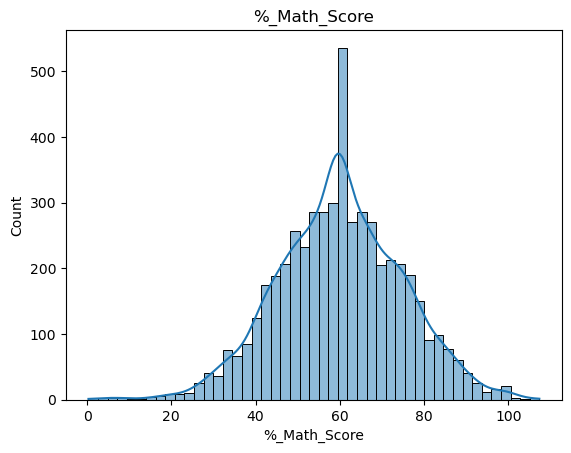

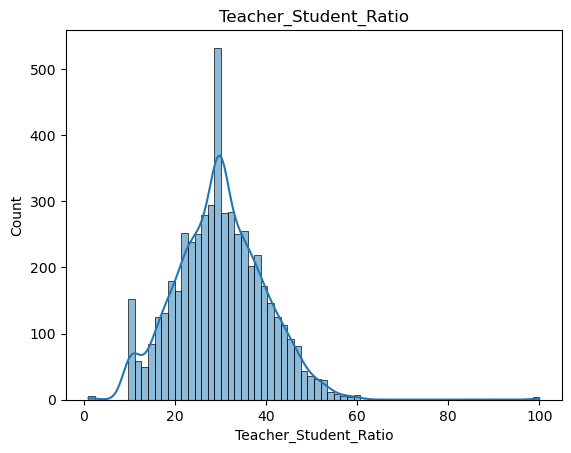

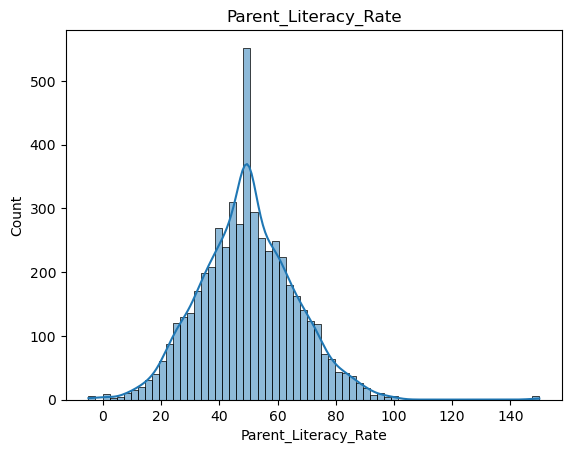

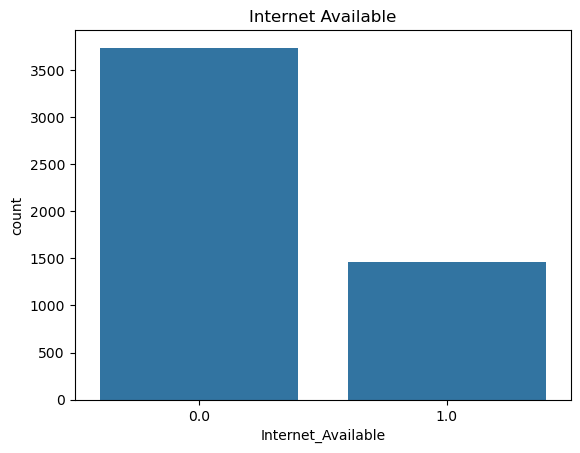

In [8]:
print("--- 3. EDA ---")
print("\nSummary:")
display(df.describe())
for col in ['%_Math_Score', 'Teacher_Student_Ratio', 'Parent_Literacy_Rate']:
    if col in df.columns:
        sns.histplot(df[col], kde=True)
        plt.title(col)
        plt.show()
if 'Internet_Available' in df.columns:
    sns.countplot(x=df['Internet_Available'])
    plt.title('Internet Available')
    plt.show()

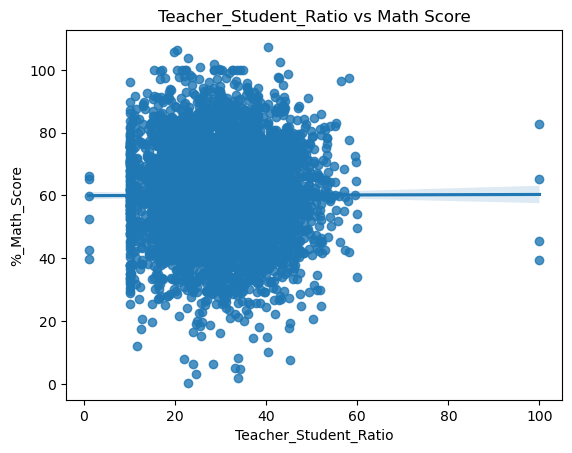

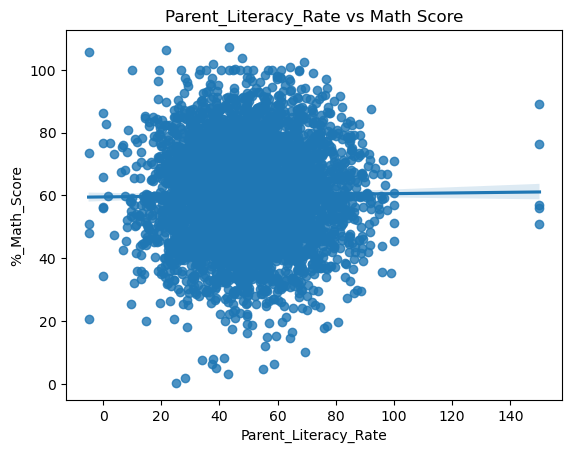

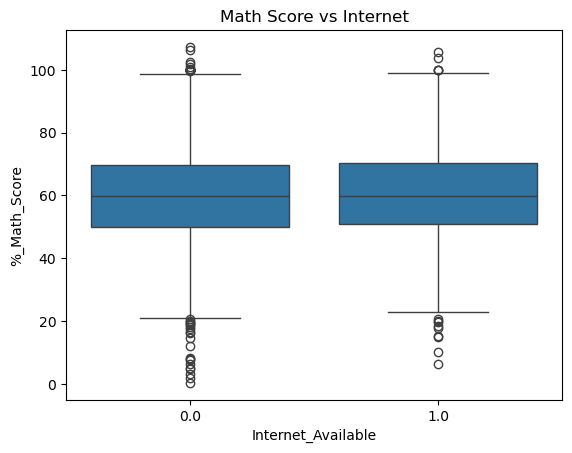

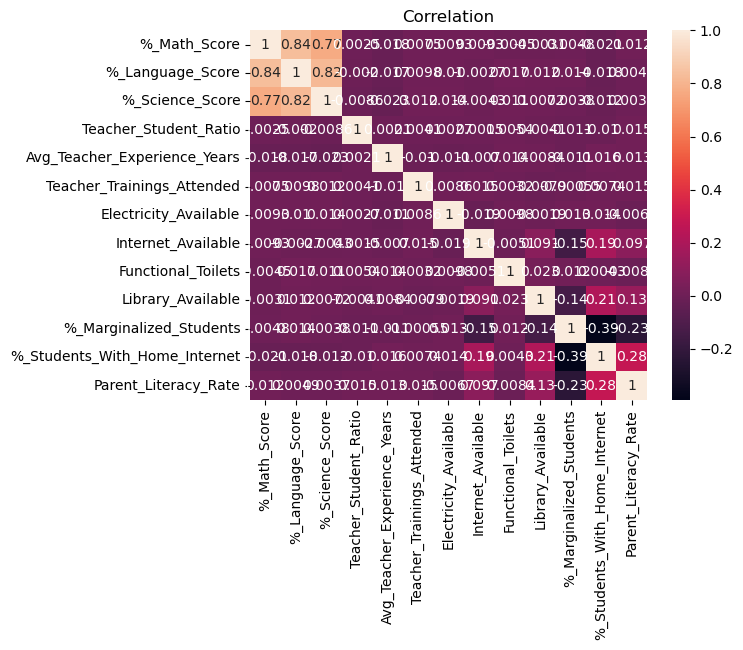

In [9]:
pairs = ['Teacher_Student_Ratio', 'Parent_Literacy_Rate']
for col in pairs:
    if col in df.columns:
        sns.regplot(x=col, y='%_Math_Score', data=df)
        plt.title(f"{col} vs Math Score")
        plt.show()
if 'Internet_Available' in df.columns:
    sns.boxplot(x=df['Internet_Available'], y=df['%_Math_Score'])
    plt.title("Math Score vs Internet")
    plt.show()
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True)
plt.title("Correlation")
plt.show()

In [13]:
if all(c in df.columns for c in ['%_Math_Score','%_Language_Score','%_Science_Score']):
    
    df['Avg_Overall_Score'] = df[['%_Math_Score','%_Language_Score','%_Science_Score']].mean(axis=1)

    from sklearn.linear_model import LinearRegression
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error, r2_score

    X = df[['Teacher_Student_Ratio','Parent_Literacy_Rate']].fillna(df.median(numeric_only=True))
    y = df['Avg_Overall_Score']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression().fit(X_train, y_train)
    pred = model.predict(X_test)

    print("Model R2:", r2_score(y_test, pred))
    print("MAE:", mean_absolute_error(y_test, pred))

else:
    print("Required columns not found")

Model R2: -0.0007447968175542385
MAE: 12.612448268699346
